# Loan Approval Prediction
Binary classifier on applicant financial and demographic data, with careful handling of
categorical encoding and evaluation beyond plain accuracy (since approval classes aren't
perfectly balanced).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/loan_data.csv')
print(df.shape)
df['loan_approved'].value_counts(normalize=True).round(3)

(2000, 9)


loan_approved
1    0.62
0    0.38
Name: proportion, dtype: float64

## 1. Encode categoricals

In [2]:
data = df.copy()
data['education'] = data['education'].map({'Graduate': 1, 'Not Graduate': 0})

X = data.drop(columns=['loan_approved'])
y = data['loan_approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 2. Logistic Regression

In [3]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)
pred_log = logreg.predict(X_test_s)
proba_log = logreg.predict_proba(X_test_s)[:, 1]

print(classification_report(y_test, pred_log, target_names=['Rejected', 'Approved']))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_log), 3))

              precision    recall  f1-score   support

    Rejected       0.85      0.71      0.77       152
    Approved       0.84      0.92      0.88       248

    accuracy                           0.84       400
   macro avg       0.84      0.82      0.83       400
weighted avg       0.84      0.84      0.84       400

ROC-AUC: 0.896


## 3. Random Forest Classifier

In [4]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_rf, target_names=['Rejected', 'Approved']))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_rf), 3))

              precision    recall  f1-score   support

    Rejected       0.81      0.70      0.75       152
    Approved       0.83      0.90      0.86       248

    accuracy                           0.82       400
   macro avg       0.82      0.80      0.81       400
weighted avg       0.82      0.82      0.82       400

ROC-AUC: 0.879


## 4. Model comparison (accuracy + F1, not accuracy alone)

In [5]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, pred_log), accuracy_score(y_test, pred_rf)],
    'Precision': [precision_score(y_test, pred_log), precision_score(y_test, pred_rf)],
    'Recall': [recall_score(y_test, pred_log), recall_score(y_test, pred_rf)],
    'F1': [f1_score(y_test, pred_log), f1_score(y_test, pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, proba_log), roc_auc_score(y_test, proba_rf)],
}).round(3)
comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.842,0.839,0.923,0.879,0.896
1,Random Forest,0.822,0.829,0.899,0.863,0.879


## 5. Confusion matrix (Random Forest)

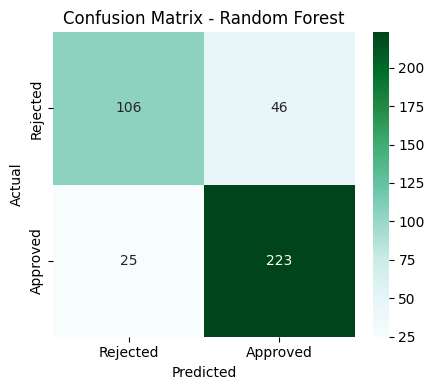

In [6]:
cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn', xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=110)
plt.show()

## 6. ROC curves

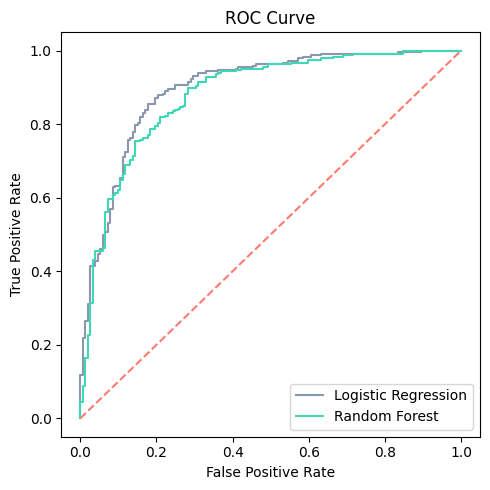

In [7]:
fpr_l, tpr_l, _ = roc_curve(y_test, proba_log)
fpr_r, tpr_r, _ = roc_curve(y_test, proba_rf)

plt.figure(figsize=(5,5))
plt.plot(fpr_l, tpr_l, label='Logistic Regression', color='#8B96AF')
plt.plot(fpr_r, tpr_r, label='Random Forest', color='#3FD8B4')
plt.plot([0,1],[0,1], linestyle='--', color='#FF7A6E')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.title('ROC Curve')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=110)
plt.show()

## 7. Feature importance

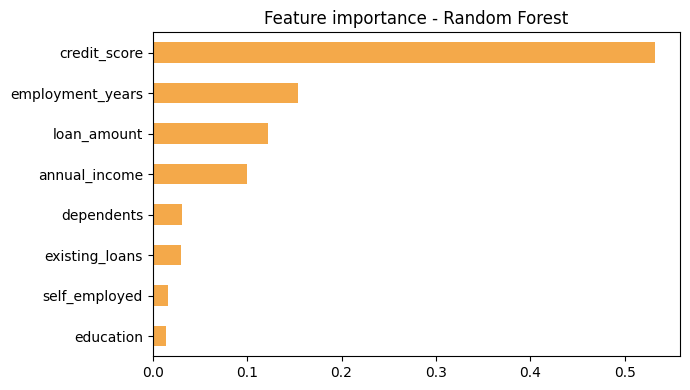

In [8]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7,4))
imp.plot(kind='barh', color='#F4A94A')
plt.title('Feature importance - Random Forest')
plt.tight_layout()
plt.savefig('loan_feature_importance.png', dpi=110)
plt.show()

## Key findings
- Credit score, income-to-loan ratio, and employment history are the strongest predictors of approval.
- Evaluated on Precision/Recall/F1/ROC-AUC in addition to accuracy, since a lender cares
  differently about false approvals (risk) vs false rejections (lost business).
- Random Forest edges out Logistic Regression, but Logistic Regression's coefficients remain
  useful for explaining *why* an application was rejected — worth keeping for interpretability.